# Visualisation de la cascade wavelet

Ce notebook est adapté aux sorties de `wave_cascade_generator.py`.

Objectif de la cascade :

```text
cA2
-> diffusion j2 -> [cH2, cV2, cD2]
-> IDWT -> cA1
-> diffusion j1 -> [cH1, cV1, cD1]
-> IDWT -> image finale
```

Le notebook :

1. recharge les coefficients réels `j2`, `j1` ;
2. recharge les sorties de la cascade générée ;
3. compare les coefficients à chaque niveau ;
4. compare les approximations reconstruites intermédiaires (`cA1`) ;
5. compare les **images finales** ;
6. calcule le **FID / PhyFID sur l'image finale** et le **FID Inception sur les coefficients ondelettes natifs**.


---
## Imports et utilitaires

In [39]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset
import pywt





def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "wave_diffusion.py").exists() and (candidate / "lib").exists():
            return candidate
    raise RuntimeError("Impossible de trouver la racine du projet RT-Diffusion.")

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT =", project_root)
print("DEVICE =", DEVICE)


PROJECT_ROOT = /home/chapuissamuel/Documents/code/RT-Diffusion
DEVICE = cpu


In [40]:
def load_pt_dataset(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def ensure_tensor(x):
    return x if torch.is_tensor(x) else torch.as_tensor(x)


def squeeze_channel(images):
    images = ensure_tensor(images)
    if images.ndim == 4 and images.shape[1] == 1:
        return images[:, 0]
    return images


def print_dataset_summary(name, images):
    tensor = ensure_tensor(images).float()
    print(
        f"{name:<28} shape={tuple(tensor.shape)!s:<18} dtype={tensor.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, title=None, colorbar=False):
    images = ensure_tensor(images)
    if images.ndim == 4 and images.shape[1] == 1:
        images = images[:, 0]

    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy()
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    plt.show()


def reconstruct_wavelet_sample(coeffs, wavelet="db1", mode="periodization"):
    coeffs = ensure_tensor(coeffs).detach().cpu().numpy()
    cA = coeffs[0]
    cH = coeffs[1]
    cV = coeffs[2]
    cD = coeffs[3]
    return pywt.idwt2((cA, (cH, cV, cD)), wavelet=wavelet, mode=mode)


def reconstruct_all_wavelet_samples(coeffs_array, wavelet="db1", mode="periodization"):
    coeffs_array = ensure_tensor(coeffs_array)
    return np.stack([
        reconstruct_wavelet_sample(coeffs, wavelet=wavelet, mode=mode)
        for coeffs in coeffs_array
    ], axis=0)


def upsample_approximation_to_image(approximation, current_level, wavelet="db1", mode="periodization"):
    """
    Propage une approximation cA_j jusqu'a l'espace image 64x64 via des IDWT
    successives avec details nuls aux niveaux plus fins.

    Cela permet d'evaluer un niveau j dans le meme espace que l'encodeur PhyFID
    final (1x64x64), sans entrainer un nouvel encodeur specifique aux coefficients.
    """
    approximation = ensure_tensor(approximation).detach().cpu().numpy().astype(np.float32)
    images = approximation
    for level in range(current_level, 0, -1):
        zeros = np.zeros_like(images, dtype=np.float32)
        images = np.stack([
            pywt.idwt2((img, (zero, zero, zero)), wavelet=wavelet, mode=mode)
            for img, zero in zip(images, zeros)
        ], axis=0)
    return images.astype(np.float32)


def reconstruct_level_projection(coeffs_array, level, wavelet="db1", mode="periodization"):
    """
    Reconstruit un echantillon de coefficients j en image 64x64 partielle.

    - j1 : reconstruction directe vers l'image finale.
    - j2 : reconstruction vers cA1 puis propagation en 64x64 avec details j1 nuls.
    - j3 : reconstruction vers cA2, puis cA1, puis 64x64 avec details plus fins nuls.

    Attention : ce n'est pas un PhyFID sur les coefficients bruts, mais un PhyFID
    sur leur projection dans l'espace image. C'est adapte pour localiser a quelle
    echelle la cascade commence a se degrader avec l'encodeur final disponible.
    """
    coeffs_array = ensure_tensor(coeffs_array)
    approx = reconstruct_all_wavelet_samples(coeffs_array, wavelet=wavelet, mode=mode)
    if level == 1:
        return approx.astype(np.float32)
    return upsample_approximation_to_image(
        approx,
        current_level=level - 1,
        wavelet=wavelet,
        mode=mode,
    )


def build_level_metric_inputs(real_coeffs, generated_coeffs, level, *, wavelet="db1", mode="periodization"):
    real_images = reconstruct_level_projection(real_coeffs[level], level, wavelet=wavelet, mode=mode)
    generated_images = reconstruct_level_projection(generated_coeffs[level], level, wavelet=wavelet, mode=mode)

    n_images = min(1000, len(real_images) // 2, len(generated_images))
    if n_images == 0:
        raise ValueError(f"Pas assez d'echantillons pour calculer les metriques au niveau j{level}.")

    reference = real_images[:n_images]
    datasets = {
        "val vs val": real_images[n_images:2 * n_images],
        f"val vs generated j{level}": generated_images[:n_images],
    }
    return reference, datasets, n_images


def to_numpy_images(images):
    images = squeeze_channel(images)
    return ensure_tensor(images).detach().cpu().numpy().astype(np.float32)


def prepare_images_for_fid(images):
    """Convertit NHW/NCHW/NHWC en RGB NCHW dans [0, 1]."""
    original_dtype = torch.as_tensor(images).dtype
    images = torch.as_tensor(images).detach().cpu().float()

    if images.ndim == 3:
        images = images.unsqueeze(1)
    elif images.ndim == 4 and images.shape[-1] in (1, 3) and images.shape[1] not in (1, 3):
        images = images.permute(0, 3, 1, 2)
    if images.ndim != 4:
        raise ValueError(f"Format non supporte: {tuple(images.shape)}")

    if original_dtype == torch.uint8 or images.max() > 2:
        images = images / 255.0
    elif images.min() < 0 and images.max() <= 1:
        images = (images + 1.0) / 2.0

    images = images.clamp(0.0, 1.0)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    if images.shape[1] != 3:
        raise ValueError(f"FID attend 1 ou 3 canaux, recu: {images.shape[1]}")
    return images


def extract_fid_features(images, model, batch_size, device):
    images = prepare_images_for_fid(images)
    loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)
    features = []

    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            prediction = model(batch.to(device))[0]
            if prediction.shape[-2:] != (1, 1):
                prediction = adaptive_avg_pool2d(prediction, output_size=(1, 1))
            features.append(prediction.flatten(1).cpu().numpy())

    return np.concatenate(features, axis=0)


def fid_from_features(reference_features, compared_features):
    reference_mu = np.mean(reference_features, axis=0)
    reference_sigma = np.cov(reference_features, rowvar=False)
    compared_mu = np.mean(compared_features, axis=0)
    compared_sigma = np.cov(compared_features, rowvar=False)
    return max(0.0, float(pytorch_fid_distance(reference_mu, reference_sigma, compared_mu, compared_sigma)))


def compute_inception_fid_scores(reference_images, datasets, n_images, dims=64, batch_size=25, device=DEVICE):
    fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[dims]
    fid_model = InceptionV3([fid_block]).to(device)

    reference_features = extract_fid_features(reference_images[:n_images], fid_model, batch_size, device)
    scores = {}
    for name, dataset in datasets.items():
        compared_features = extract_fid_features(dataset[:n_images], fid_model, batch_size, device)
        scores[name] = fid_from_features(reference_features, compared_features)

    del fid_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return scores


def wavelet_coeffs_to_single_channel_images(coeffs, wavelet="db1", mode="periodization"):
    coeffs = ensure_tensor(coeffs)
    if coeffs.ndim == 4 and coeffs.shape[1] >= 4:
        return reconstruct_all_wavelet_samples(coeffs[:, :4], wavelet=wavelet, mode=mode)
    return to_numpy_images(coeffs)


---
## Configuration

In [ ]:
CASCADE_LEVELS = [2, 1]
COARSE_LEVEL = max(CASCADE_LEVELS)
COARSE_KEY = COARSE_LEVEL + 1
DATASET = "validation"  # training / validation / test

DATA_ROOT = project_root / "data" / "RT64" / "processed"
OUTPUT_DIR = project_root / "outputs" / "generated" / "cascade_sgm"
CSV_DIR = project_root / "outputs" / "logs" / "cascade_sgm" 
WAVELET = "db1"
BORDER_MODE = "periodization"
N_SAMPLES = 8
SEED = 0

REAL_COEFF_PATHS = {
    level: DATA_ROOT / f"j{level}_{DATASET}.pt"
    for level in CASCADE_LEVELS
}

LOSS_PATHS = {
    COARSE_KEY: CSV_DIR / f"coarse_cA{COARSE_LEVEL}_RT64.csv",
    **{level: CSV_DIR / f"wave_j{level}_RT64.csv" for level in CASCADE_LEVELS},
}

GENERATED_COEFF_PATHS = {
    COARSE_KEY: OUTPUT_DIR / f"j{COARSE_LEVEL}_initial_cA.pt",
    **{level: OUTPUT_DIR / f"j{level}_generated_coefficients.pt" for level in CASCADE_LEVELS},
}

RECONSTRUCTED_CA_PATHS = {
    level - 1: OUTPUT_DIR / f"j{level - 1}_reconstructed_cA.pt"
    for level in CASCADE_LEVELS
    if level > 1
}

FINAL_GENERATED_IMAGES_PT = OUTPUT_DIR / "generated_images.pt"

PHYFID_ENCODER = project_root / "outputs" / "phyFID" / "64phyfid_encoder.pt"
PHYFID_BATCH_SIZE = 128

FID_DIMS = 64
FID_BATCH_SIZE = 25
FID_DEVICE = DEVICE


---
## Chargement des données de la cascade

In [ ]:
real_coeffs = {level: load_pt_dataset(path) for level, path in REAL_COEFF_PATHS.items()}
generated_coeffs = {level: load_pt_dataset(path) for level, path in GENERATED_COEFF_PATHS.items()}
reconstructed_ca = {level: load_pt_dataset(path) for level, path in RECONSTRUCTED_CA_PATHS.items()}
final_generated_images = load_pt_dataset(FINAL_GENERATED_IMAGES_PT)

final_real_images = reconstruct_all_wavelet_samples(
    real_coeffs[1],
    wavelet=WAVELET,
    mode=BORDER_MODE,
)

for level in CASCADE_LEVELS:
    print_dataset_summary(f"real coeffs j{level}", real_coeffs[level])
    print_dataset_summary(f"generated coeffs j{level}", generated_coeffs[level])

print_dataset_summary(f"initial cA{COARSE_LEVEL}", generated_coeffs[COARSE_KEY])
for level in sorted(reconstructed_ca, reverse=True):
    print_dataset_summary(f"reconstructed cA{level}", reconstructed_ca[level])
print_dataset_summary("final real images", final_real_images)
print_dataset_summary("final generated images", final_generated_images)


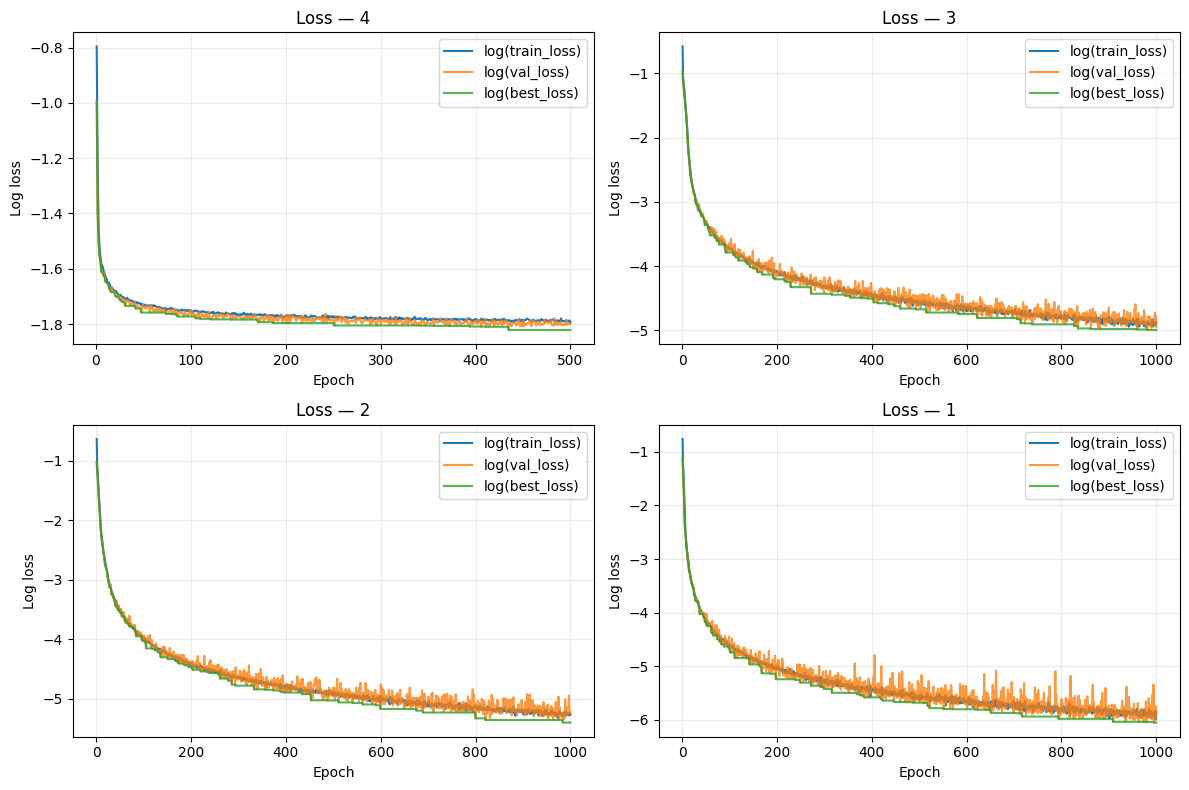

In [43]:
def plot_loss_curves(csv_paths, save=False, save_path="loss_curves.png"):
    """
    Affiche une courbe de loss par fichier CSV.

    Parameters
    ----------
    csv_paths : dict
        Dictionnaire de la forme {nom_ou_niveau: chemin_csv}.
    """

    n_curves = len(csv_paths)
    n_cols = 2
    n_rows = int(np.ceil(n_curves / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 4 * n_rows),
        squeeze=False,
    )

    axes = axes.ravel()
    eps = 1e-12

    for index, (name, path) in enumerate(csv_paths.items()):
        path = Path(path)

        if not path.exists():
            raise FileNotFoundError(f"Fichier de loss introuvable : {path}")

        data = np.genfromtxt(
            path,
            delimiter=",",
            names=True,
            dtype=None,
            encoding="utf-8",
        )

        if data.dtype.names is None:
            raise ValueError(
                f"Impossible de lire les colonnes du fichier {path}."
            )

        required_columns = {"epoch", "train_loss"}
        missing_columns = required_columns.difference(data.dtype.names)

        if missing_columns:
            raise ValueError(
                f"Colonnes manquantes dans {path}: {sorted(missing_columns)}. "
                f"Colonnes disponibles: {data.dtype.names}"
            )

        epochs = np.atleast_1d(data["epoch"])
        train_loss = np.atleast_1d(data["train_loss"])

        val_loss = (
            np.atleast_1d(data["val_loss"])
            if "val_loss" in data.dtype.names
            else None
        )

        best_loss = (
            np.atleast_1d(data["best_loss"])
            if "best_loss" in data.dtype.names
            else None
        )

        axis = axes[index]

        axis.plot(
            epochs,
            np.log(np.clip(train_loss, eps, None)),
            label="log(train_loss)",
        )

        if val_loss is not None:
            axis.plot(
                epochs,
                np.log(np.clip(val_loss, eps, None)),
                label="log(val_loss)",
                alpha=0.8,
            )

        if best_loss is not None:
            axis.plot(
                epochs,
                np.log(np.clip(best_loss, eps, None)),
                label="log(best_loss)",
                alpha=0.8,
            )

        axis.set_xlabel("Epoch")
        axis.set_ylabel("Log loss")
        axis.set_title(f"Loss — {name}")
        axis.grid(alpha=0.25)
        axis.legend()

    # Désactive les sous-figures inutilisées
    for index in range(n_curves, len(axes)):
        axes[index].axis("off")

    fig.tight_layout()

    if save:
        fig.savefig(save_path, bbox_inches="tight", dpi=200)

    plt.show()


plot_loss_curves(LOSS_PATHS, save=True, save_path=OUTPUT_DIR / "loss_curves.png")

---
## Fonctions de visualisation

In [44]:
def plot_wavelet_level_comparison(real_data,
                                  generated_data,
                                  level,
                                  n_examples=3,
                                  seed=0,
                                  channel_titles=None,
                                  cmap="gray"):
    real_data = ensure_tensor(real_data)
    generated_data = ensure_tensor(generated_data)

    n_examples = min(n_examples, len(real_data), len(generated_data))
    rng = np.random.default_rng(seed)
    indices = rng.choice(min(len(real_data), len(generated_data)), size=n_examples, replace=False)

    if channel_titles is None:
        channel_titles = ["Approximation cA", "Horizontal cH", "Vertical cV", "Diagonal cD"]

    fig, axes = plt.subplots(4, 2 * n_examples, figsize=(4 * n_examples, 8))

    for example, idx in enumerate(indices):
        real_coeff = real_data[idx]
        gen_coeff = generated_data[idx]
        c0 = example * 2

        axes[0, c0].imshow(real_coeff[0], cmap=cmap)
        axes[0, c0].set_title(f"Ref j{level}\n{channel_titles[0]}")
        axes[0, c0 + 1].imshow(gen_coeff[0], cmap=cmap)
        axes[0, c0 + 1].set_title(f"Gen j{level}\n{channel_titles[0]}")

        axes[1, c0].imshow(real_coeff[1], cmap=cmap)
        axes[1, c0].set_title(channel_titles[1])
        axes[1, c0 + 1].imshow(gen_coeff[1], cmap=cmap)
        axes[1, c0 + 1].set_title(channel_titles[1])

        axes[2, c0].imshow(real_coeff[2], cmap=cmap)
        axes[2, c0].set_title(channel_titles[2])
        axes[2, c0 + 1].imshow(gen_coeff[2], cmap=cmap)
        axes[2, c0 + 1].set_title(channel_titles[2])

        axes[3, c0].imshow(real_coeff[3], cmap=cmap)
        axes[3, c0].set_title(channel_titles[3])
        axes[3, c0 + 1].imshow(gen_coeff[3], cmap=cmap)
        axes[3, c0 + 1].set_title(channel_titles[3])

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()


def plot_single_channel_comparison(real_images,
                                   generated_images,
                                   title,
                                   n_examples=6,
                                   seed=0,
                                   cmap="gray"):
    real_images = squeeze_channel(real_images)
    generated_images = squeeze_channel(generated_images)

    n_examples = min(n_examples, len(real_images), len(generated_images))
    rng = np.random.default_rng(seed)
    indices = rng.choice(min(len(real_images), len(generated_images)), size=n_examples, replace=False)

    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 3 * n_examples))
    if n_examples == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        ref = ensure_tensor(real_images[idx]).detach().cpu().numpy()
        gen = ensure_tensor(generated_images[idx]).detach().cpu().numpy()
        err = np.abs(ref - gen)

        vmin = min(ref.min(), gen.min())
        vmax = max(ref.max(), gen.max())

        axes[row, 0].imshow(ref, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, 0].set_title(f"Reference\nidx={idx}")

        axes[row, 1].imshow(gen, cmap=cmap, vmin=vmin, vmax=vmax)
        axes[row, 1].set_title(f"Generated\nidx={idx}")

        axes[row, 2].imshow(err, cmap="magma")
        axes[row, 2].set_title(f"|Error|\nMAE={err.mean():.3e}")

        for ax in axes[row]:
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


---
## Verification du coarse

In [ ]:
show_grid(generated_coeffs[COARSE_KEY], n=16, cols=4, seed=SEED, title=f"Grille cA{COARSE_LEVEL} générée")
show_grid(real_coeffs[COARSE_LEVEL][:, 0:1], n=16, cols=4, seed=SEED, title=f"Grille cA{COARSE_LEVEL} vraie")


In [ ]:
from lib.PhyFID.encoder import*
from lib.PhyFID.metrics import*

PHYFID_ENCODER = f"../outputs/phyFID/coarse_cA{COARSE_LEVEL}_phyfid_encoder.pt"
PHYFID_STATS = f"../outputs/phyFID/coarse_cA{COARSE_LEVEL}_phyfid_val_stats.npz"
PHYFID_BATCH_SIZE = 128
PHYFID_N_IMAGES = min(1000, len(real_coeffs[COARSE_LEVEL]), len(generated_coeffs[COARSE_KEY]))
phyfid_reference = real_coeffs[COARSE_LEVEL][:PHYFID_N_IMAGES, 0:1]
phyfid_generated = generated_coeffs[COARSE_KEY][:PHYFID_N_IMAGES]

phyfid_scores = compare_datasets(phyfid_reference, phyfid_generated, PHYFID_ENCODER, batch_size=PHYFID_BATCH_SIZE)
print(f"PhyFID scores for cA{COARSE_LEVEL}: {phyfid_scores}")

---
## Comparaison des coefficients générés à chaque niveau

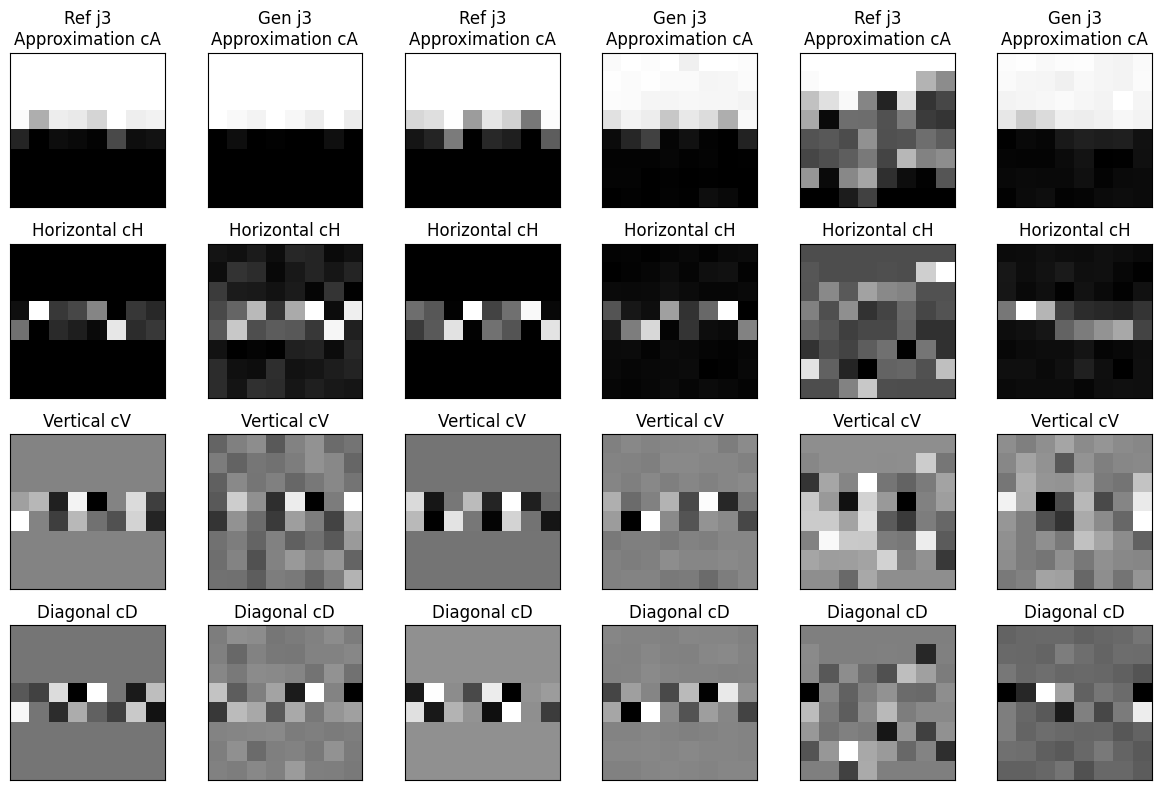

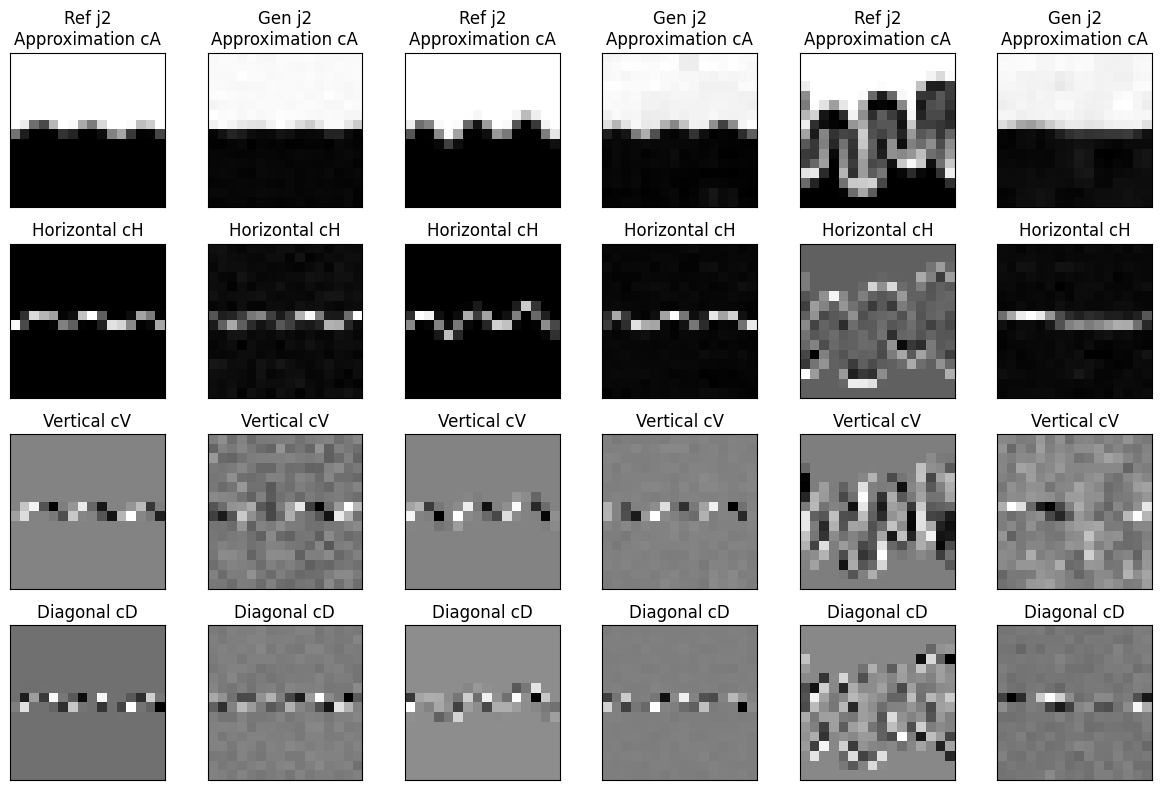

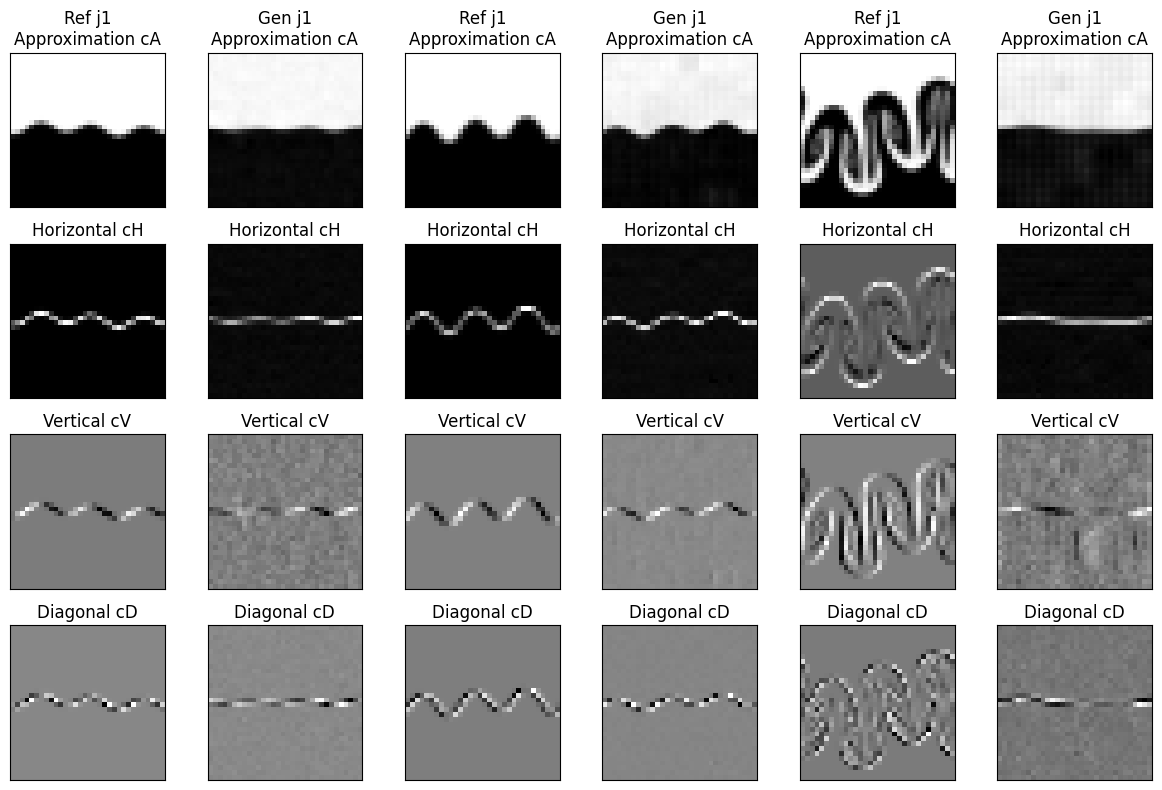

In [47]:
for level in CASCADE_LEVELS:
    plot_wavelet_level_comparison(
        real_coeffs[level],
        generated_coeffs[level],
        level=level,
        n_examples=3,
        seed=SEED,
        cmap="gray",
    )


---
## Comparaison des approximations intermédiaires reconstruites

In [ ]:
for level in sorted(reconstructed_ca, reverse=True):
    plot_single_channel_comparison(
        real_coeffs[level][:, 0:1],
        reconstructed_ca[level],
        title=f"Comparaison de cA{level} (après IDWT de j{level + 1})",
        n_examples=6,
        seed=SEED,
    )


---
## Comparaison des images finales reconstruites

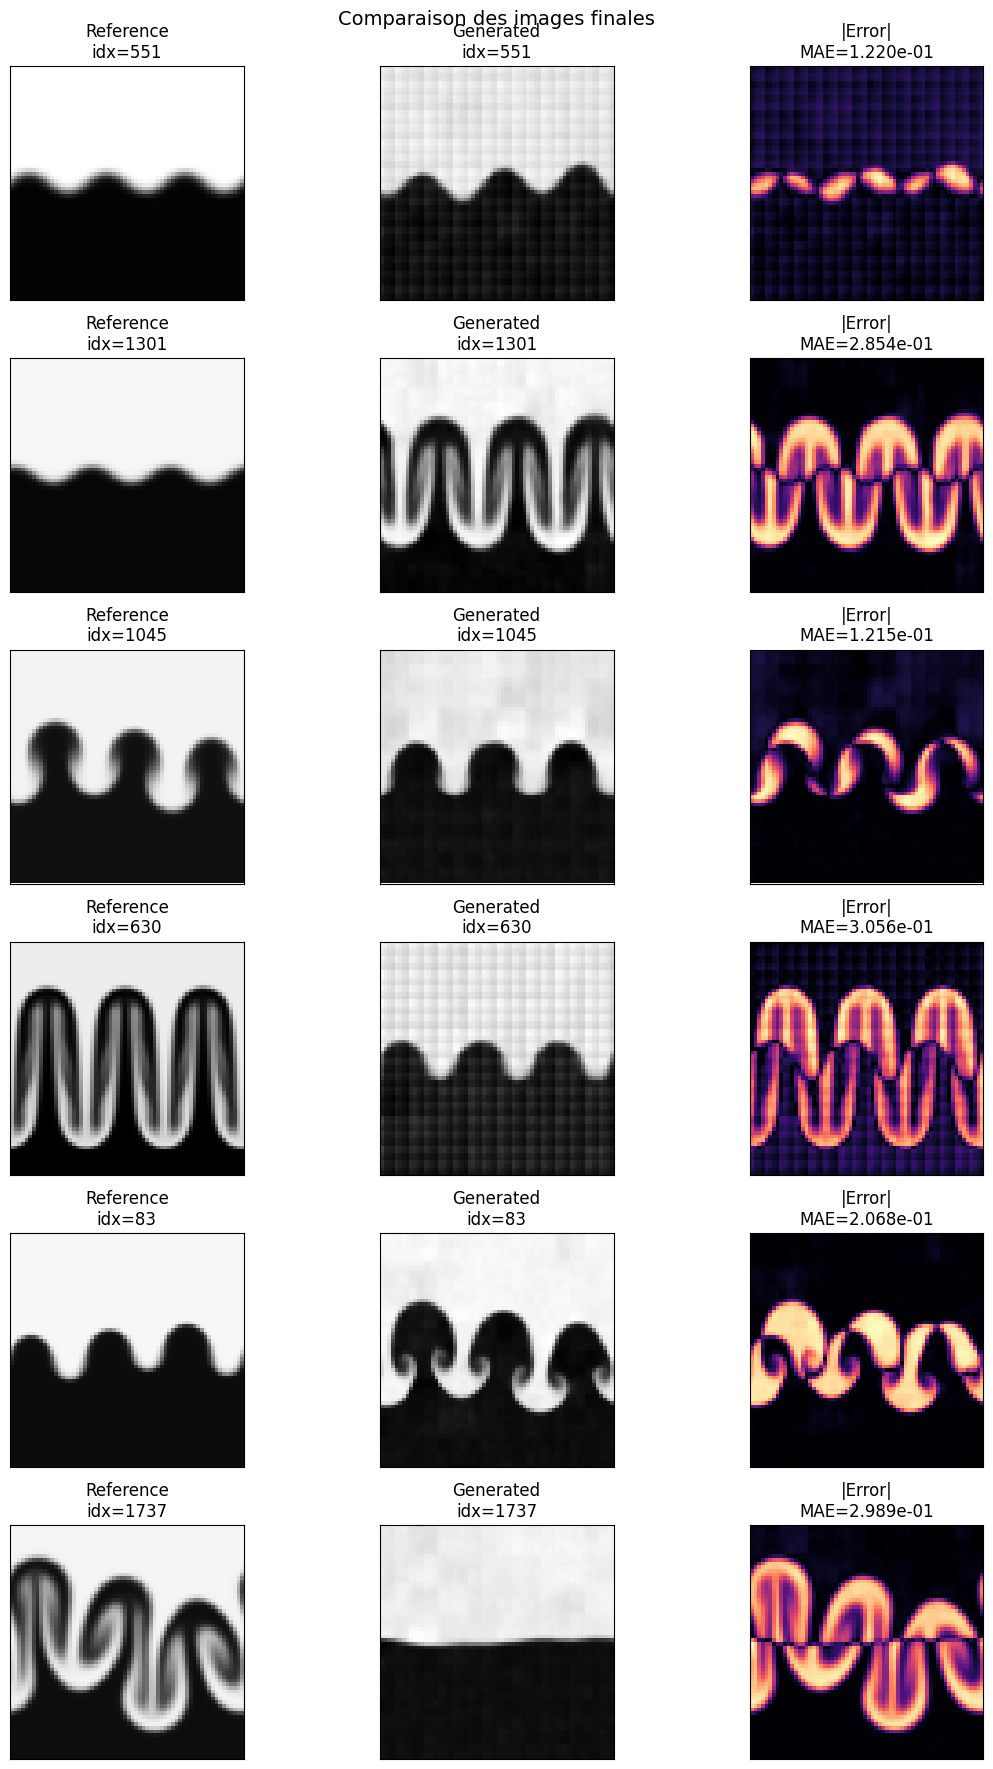

In [49]:
plot_single_channel_comparison(
    final_real_images,
    final_generated_images,
    title="Comparaison des images finales",
    n_examples=6,
    seed=SEED,
)


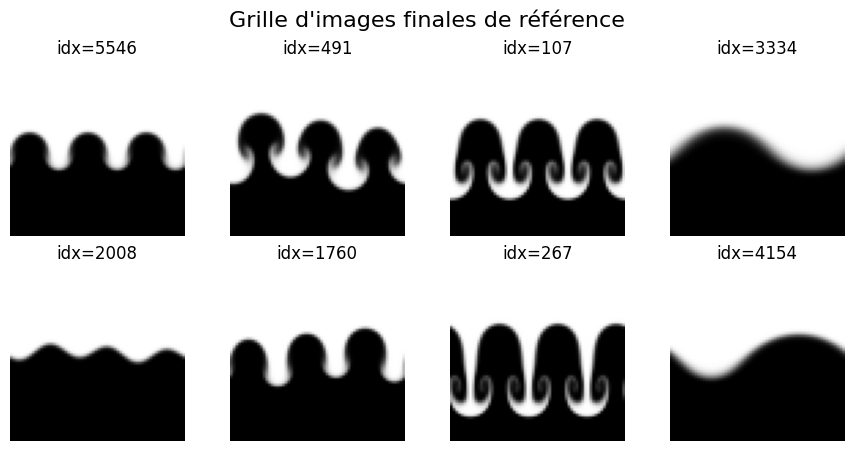

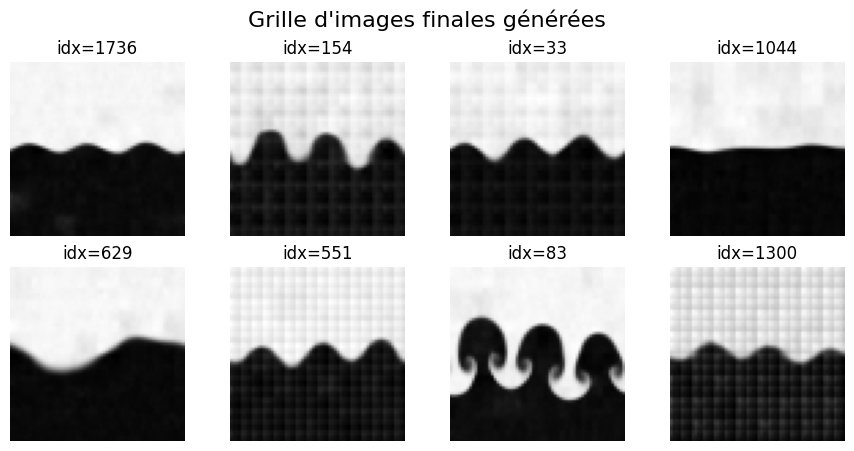

In [50]:
show_grid(final_real_images, n=N_SAMPLES, cols=4, seed=SEED, title="Grille d'images finales de référence")
show_grid(final_generated_images, n=N_SAMPLES, cols=4, seed=SEED, title="Grille d'images finales générées")


---
## Figures rapport : cascade wavelet finale

Cette section reconstruit les deux figures utilisées dans le chapitre 5 du rapport. Elle est volontairement autonome : elle recharge directement les coefficients `j1` réels, les coefficients `j1` générés par la cascade et les images finales générées.


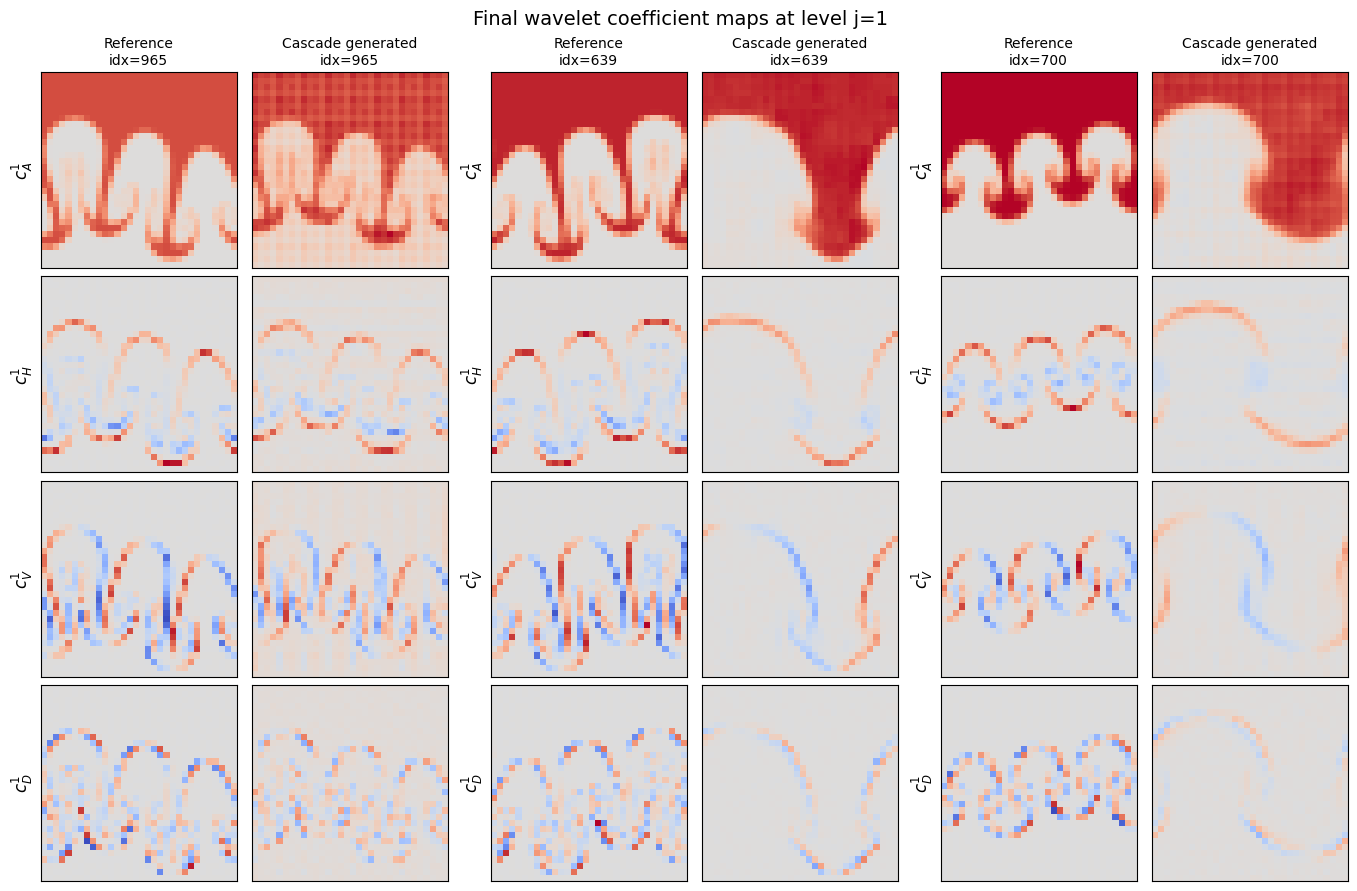

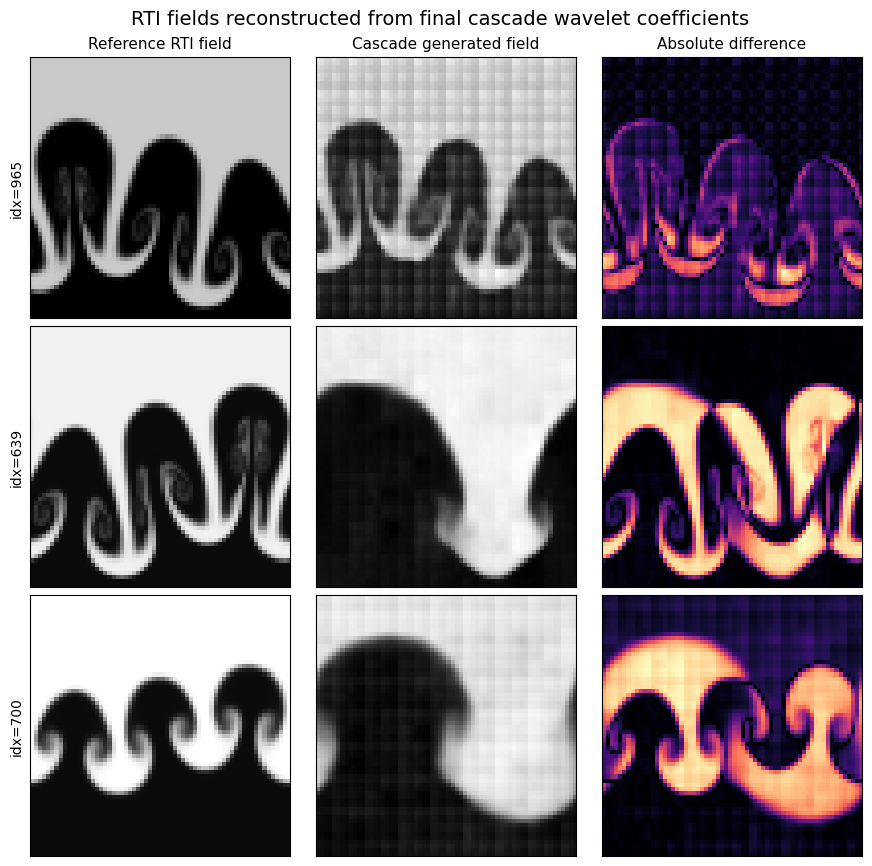

Saved:
/home/chapuissamuel/Documents/code/RT-Diffusion/doc/BDRPReportTemplate/figures/ch5/wavelet_cascade_coefficients_comparison.png
/home/chapuissamuel/Documents/code/RT-Diffusion/doc/BDRPReportTemplate/figures/ch5/wavelet_cascade_reconstruction_comparison.png


In [51]:
REPORT_FIGURE_DIR = project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch5"
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_REAL_J1 = DATA_ROOT / f"j1_{DATASET}.pt"
REPORT_GENERATED_J1 = OUTPUT_DIR / "j1_generated_coefficients.pt"
REPORT_GENERATED_IMAGES = OUTPUT_DIR / "generated_images.pt"

report_real_coeffs = load_pt_dataset(REPORT_REAL_J1).float()
report_generated_coeffs = load_pt_dataset(REPORT_GENERATED_J1).float()
report_generated_images = load_pt_dataset(REPORT_GENERATED_IMAGES).float()

# Fixed indices reproduce the figures inserted in the report.
REPORT_INDICES = [965, 639, 700]
REPORT_INDICES = [
    index for index in REPORT_INDICES
    if index < min(len(report_real_coeffs), len(report_generated_coeffs), len(report_generated_images))
]

if not REPORT_INDICES:
    raise ValueError("Aucun indice valide pour construire les figures du rapport.")

channel_names = [r"$c_A^1$", r"$c_H^1$", r"$c_V^1$", r"$c_D^1$"]

fig, axes = plt.subplots(4, 2 * len(REPORT_INDICES), figsize=(4.5 * len(REPORT_INDICES), 8.8), constrained_layout=True)
if len(REPORT_INDICES) == 1:
    axes = axes.reshape(4, 2)

for example, index in enumerate(REPORT_INDICES):
    c0 = 2 * example
    for channel in range(4):
        reference = report_real_coeffs[index, channel].detach().cpu().numpy()
        generated = report_generated_coeffs[index, channel].detach().cpu().numpy()
        vmax = max(abs(reference).max(), abs(generated).max())
        vmin = -vmax

        axes[channel, c0].imshow(reference, cmap="coolwarm", vmin=vmin, vmax=vmax)
        axes[channel, c0 + 1].imshow(generated, cmap="coolwarm", vmin=vmin, vmax=vmax)
        axes[channel, c0].set_ylabel(channel_names[channel], fontsize=12)

        for axis in (axes[channel, c0], axes[channel, c0 + 1]):
            axis.set_xticks([])
            axis.set_yticks([])

        if channel == 0:
            axes[channel, c0].set_title(f"Reference\nidx={index}", fontsize=10)
            axes[channel, c0 + 1].set_title(f"Cascade generated\nidx={index}", fontsize=10)

fig.suptitle("Final wavelet coefficient maps at level j=1", fontsize=14)
coefficients_figure_path = REPORT_FIGURE_DIR / "wavelet_cascade_coefficients_comparison.png"
# fig.savefig(coefficients_figure_path, bbox_inches="tight", dpi=220)
plt.show()


def reconstruct_report_sample(coefficients):
    coefficients = coefficients.detach().cpu().numpy()
    return pywt.idwt2(
        (coefficients[0], (coefficients[1], coefficients[2], coefficients[3])),
        wavelet=WAVELET,
        mode=BORDER_MODE,
    )

report_reference_images = np.stack(
    [reconstruct_report_sample(report_real_coeffs[index]) for index in REPORT_INDICES],
    axis=0,
)
report_generated_images_np = squeeze_channel(report_generated_images).detach().cpu().numpy()

fig, axes = plt.subplots(len(REPORT_INDICES), 3, figsize=(8.7, 2.85 * len(REPORT_INDICES)), constrained_layout=True)
if len(REPORT_INDICES) == 1:
    axes = axes[None, :]

for row, index in enumerate(REPORT_INDICES):
    reference = report_reference_images[row]
    generated = report_generated_images_np[index]
    error = np.abs(reference - generated)
    vmin = min(reference.min(), generated.min())
    vmax = max(reference.max(), generated.max())

    axes[row, 0].imshow(reference, cmap="gray", vmin=vmin, vmax=vmax)
    axes[row, 1].imshow(generated, cmap="gray", vmin=vmin, vmax=vmax)
    axes[row, 2].imshow(error, cmap="magma")
    axes[row, 0].set_ylabel(f"idx={index}", fontsize=10)

    for axis in axes[row]:
        axis.set_xticks([])
        axis.set_yticks([])

axes[0, 0].set_title("Reference RTI field", fontsize=11)
axes[0, 1].set_title("Cascade generated field", fontsize=11)
axes[0, 2].set_title("Absolute difference", fontsize=11)
fig.suptitle("RTI fields reconstructed from final cascade wavelet coefficients", fontsize=14)
reconstruction_figure_path = REPORT_FIGURE_DIR / "wavelet_cascade_reconstruction_comparison.png"
# fig.savefig(reconstruction_figure_path, bbox_inches="tight", dpi=220)
plt.show()

print("Saved:")
print(coefficients_figure_path)
print(reconstruction_figure_path)



---
## FID / PhyFID image finale et FID par sous-bandes

In [ ]:
# def compute_phyfid_scores(reference_images, datasets, n_images, encoder, *, batch_size=128, device=DEVICE):
#     reference_features = encode_dataset(
#         reference_images[:n_images],
#         encoder,
#         batch_size=batch_size,
#         device=device,
#     )
#     reference_mu, reference_sigma = feature_statistics(reference_features)

#     scores = {}
#     for name, dataset in datasets.items():
#         compared_features = encode_dataset(
#             dataset[:n_images],
#             encoder,
#             batch_size=batch_size,
#             device=device,
#         )
#         compared_mu, compared_sigma = feature_statistics(compared_features)
#         scores[name] = frechet_distance(reference_mu, reference_sigma, compared_mu, compared_sigma)
#     return scores


# def build_metric_split(reference_pool, generated_pool, *, max_images=1000, label="dataset"):
#     reference_pool = to_numpy_images(reference_pool)
#     generated_pool = to_numpy_images(generated_pool)

#     n_images = min(max_images, len(reference_pool) // 2, len(generated_pool))
#     if n_images == 0:
#         raise ValueError(f"Pas assez d'echantillons pour calculer les metriques: {label}.")

#     reference = reference_pool[:n_images]
#     datasets = {
#         "val vs val": reference_pool[n_images:2 * n_images],
#         f"val vs generated {label}": generated_pool[:n_images],
#     }
#     return reference, datasets, n_images




# def compute_inception_fid_scores_with_model(reference_images, datasets, n_images, fid_model, *, batch_size=25, device=DEVICE):
#     reference_features = extract_fid_features(reference_images[:n_images], fid_model, batch_size, device)
#     scores = {}
#     for name, dataset in datasets.items():
#         compared_features = extract_fid_features(dataset[:n_images], fid_model, batch_size, device)
#         scores[name] = fid_from_features(reference_features, compared_features)
#     return scores

# def normalize_positive_coefficients_for_fid(reference_pool, generated_pool, *, eps=1e-8):
#     """Normalise cA avec une affine min/max fixee par le pool reel."""
#     reference_pool = to_numpy_images(reference_pool)
#     generated_pool = to_numpy_images(generated_pool)
#     ref_min = float(np.min(reference_pool))
#     ref_max = float(np.max(reference_pool))
#     scale = max(ref_max - ref_min, eps)
#     return (
#         np.clip((reference_pool - ref_min) / scale, 0.0, 1.0).astype(np.float32),
#         np.clip((generated_pool - ref_min) / scale, 0.0, 1.0).astype(np.float32),
#     )


# def normalize_signed_coefficients_for_fid(reference_pool, generated_pool, *, quantile=0.999, eps=1e-8):
#     """Normalise les details signes avec zero -> 0.5 et une echelle robuste fixee par le reel."""
#     reference_pool = to_numpy_images(reference_pool)
#     generated_pool = to_numpy_images(generated_pool)
#     scale = float(np.quantile(np.abs(reference_pool), quantile))
#     scale = max(scale, float(np.max(np.abs(reference_pool))), eps) if scale < eps else scale
#     return (
#         np.clip(0.5 + 0.5 * reference_pool / scale, 0.0, 1.0).astype(np.float32),
#         np.clip(0.5 + 0.5 * generated_pool / scale, 0.0, 1.0).astype(np.float32),
#     )


# phyfid_encoder, _ = load_encoder(PHYFID_ENCODER, device=DEVICE)
# fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[FID_DIMS]
# fid_model = InceptionV3([fid_block]).to(FID_DEVICE)

# final_real_for_metrics = to_numpy_images(final_real_images)
# final_generated_for_metrics = to_numpy_images(final_generated_images)

# print("Images finales:", final_real_for_metrics.shape, final_generated_for_metrics.shape)

# final_reference, final_datasets, FINAL_N_IMAGES = build_metric_split(
#     final_real_for_metrics,
#     final_generated_for_metrics,
#     label="final",
# )

# phyfid_scores = compute_phyfid_scores(
#     final_reference,
#     final_datasets,
#     FINAL_N_IMAGES,
#     phyfid_encoder,
#     batch_size=PHYFID_BATCH_SIZE,
#     device=DEVICE,
# )

# fid_scores_final = compute_inception_fid_scores_with_model(
#     final_reference,
#     final_datasets,
#     FINAL_N_IMAGES,
#     fid_model,
#     batch_size=FID_BATCH_SIZE,
#     device=FID_DEVICE,
# )

# print(f"Comparaison sur {FINAL_N_IMAGES} images finales (Inception: {FID_DIMS} features)")
# print(f"{'Comparaison':<30} {'PhyFID':>12} {'FID Inception':>16}")
# for name in final_datasets:
#     print(f"{name:<30} {phyfid_scores[name]:>12.4f} {fid_scores_final[name]:>16.4f}")


# base_real_images, base_generated_images = normalize_positive_coefficients_for_fid(
#     real_coeffs[3][:, 0:1],
#     generated_coeffs[4],
# )

# print("\nBase non conditionnee cA3 native normalisee:", base_real_images.shape, base_generated_images.shape)

# base_reference, base_datasets, BASE_N_IMAGES = build_metric_split(
#     base_real_images,
#     base_generated_images,
#     label="cA3",
# )

# fid_scores_base = compute_inception_fid_scores_with_model(
#     base_reference,
#     base_datasets,
#     BASE_N_IMAGES,
#     fid_model,
#     batch_size=FID_BATCH_SIZE,
#     device=FID_DEVICE,
# )

# print(f"Comparaison FID sur {BASE_N_IMAGES} bases cA3 natives (Inception: {FID_DIMS} features)")
# for name, score in fid_scores_base.items():
#     print(f"{name:<30} {score:>16.4f}")


# DETAIL_BANDS = {
#     "cH": 1,
#     "cV": 2,
#     "cD": 3,
# }

# fid_detail_band_scores = {}
# fid_detail_mean_scores = {}

# for level in CASCADE_LEVELS:
#     band_scores = {}
#     for band_name, band_index in DETAIL_BANDS.items():
#         real_band_images, generated_band_images = normalize_signed_coefficients_for_fid(
#             real_coeffs[level][:, band_index:band_index + 1],
#             generated_coeffs[level][:, band_index:band_index + 1],
#         )
#         reference, datasets, n_images = build_metric_split(
#             real_band_images,
#             generated_band_images,
#             label=f"{band_name}{level}",
#         )
#         scores = compute_inception_fid_scores_with_model(
#             reference,
#             datasets,
#             n_images,
#             fid_model,
#             batch_size=FID_BATCH_SIZE,
#             device=FID_DEVICE,
#         )
#         generated_key = f"val vs generated {band_name}{level}"
#         band_scores[band_name] = {
#             "n_images": n_images,
#             "val_vs_val": scores["val vs val"],
#             "val_vs_generated": scores[generated_key],
#         }

#     fid_detail_band_scores[level] = band_scores
#     fid_detail_mean_scores[level] = {
#         "n_images": min(band_scores[band]["n_images"] for band in DETAIL_BANDS),
#         "val_vs_val": float(np.mean([band_scores[band]["val_vs_val"] for band in DETAIL_BANDS])),
#         "val_vs_generated": float(np.mean([band_scores[band]["val_vs_generated"] for band in DETAIL_BANDS])),
#     }

# print("\nFID Inception par coefficients ondelettes natifs")
# print(f"{'Echelle':<18} {'n':>6} {'val vs val':>14} {'val vs generated':>20}")
# print(f"{'cA3':<18} {BASE_N_IMAGES:>6} {fid_scores_base['val vs val']:>14.4f} {fid_scores_base['val vs generated cA3']:>20.4f}")
# for level in CASCADE_LEVELS:
#     mean_scores = fid_detail_mean_scores[level]
#     print(
#         f"{'mean cH/cV/cD j' + str(level):<18} "
#         f"{mean_scores['n_images']:>6} "
#         f"{mean_scores['val_vs_val']:>14.4f} "
#         f"{mean_scores['val_vs_generated']:>20.4f}"
#     )

# print("\nDetail des scores FID Inception par bande native")
# print(f"{'Bande':<8} {'n':>6} {'val vs val':>14} {'val vs generated':>20}")
# for level in CASCADE_LEVELS:
#     for band_name in DETAIL_BANDS:
#         scores = fid_detail_band_scores[level][band_name]
#         print(f"{band_name + str(level):<8} {scores['n_images']:>6} {scores['val_vs_val']:>14.4f} {scores['val_vs_generated']:>20.4f}")

# del phyfid_encoder
# del fid_model
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()


Images finales: (6528, 64, 64) (2048, 64, 64)


ValueError: Les images a encoder ne correspondent pas a la resolution de l'encodeur: images=(1, 64, 64), encodeur=(1, 8, 8). Re-entraine une reference PhyFID pour cette resolution ou redimensionne les images.